In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import ( # import necessary metrics for evaluation
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [2]:
df = pd.read_csv('./dataset/DM1_game_dataset_cleaned.csv')

print(df.columns)

Index(['Name', 'YearPublished', 'GameWeight', 'MinPlayers', 'MaxPlayers',
       'MfgPlaytime', 'MfgAgeRec', 'NumAlternates', 'NumExpansions',
       'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rating',
       'HasFamily', 'Category', 'Rank', 'EngagementLevel'],
      dtype='object')


## Preprocessing

In [3]:
# Variabili CATEGORICHE (Stringhe - Da fare OneHot)
categorical_features = ['Category']

# one-hot encoding of categorical features
df = pd.get_dummies(df, columns=categorical_features, dtype=int) # get_dummies creates new columns for each category

df.drop(columns=['Name'], inplace=True)

## Partitioning

In [4]:
attributes = [col for col in df.columns if col != 'Rating']
X = df[attributes]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y) # 70% train, 30% test

## Decision Tree

In [6]:
dt = DecisionTreeClassifier()

Training (Induction)

In [7]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Test (Deduction)

In [ ]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

Evaluation

In [9]:
# scores on train and test

# 1 print train accuracy/f1 (y train vs y train predicted)
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred)) 
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print() 

# 2 print test accuracy/f1 (y test vs y test predicted)
print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred)) 
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))
# performance on test set is worse -> overfitting (loss of generalization)

Train Accuracy 1.0
Train F1-score [1. 1. 1.]

Test Accuracy 0.6491468616697136
Test F1-score [0.65018134 0.66960557 0.63336214]


In [10]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.64      0.66      0.65      1500
         Low       0.67      0.66      0.67      2172
      Medium       0.63      0.63      0.63      2892

    accuracy                           0.65      6564
   macro avg       0.65      0.65      0.65      6564
weighted avg       0.65      0.65      0.65      6564



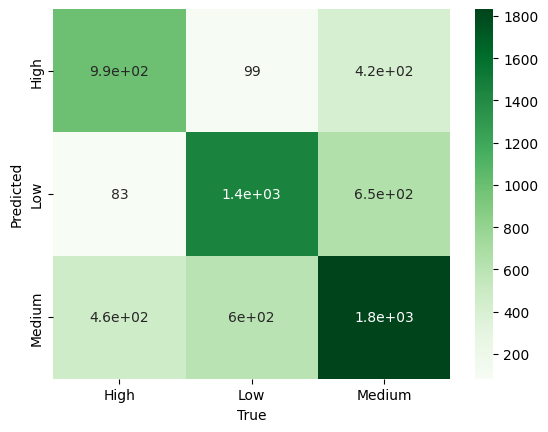

In [11]:
cf = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cf, xticklabels=dt.classes_, yticklabels=dt.classes_, annot=True, cmap="Greens")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

Feature importance

In [12]:
zipped = zip(attributes, dt.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp) # print feature importances in descending order

# the first features are the most important ones in the classification task

EngagementLevel 0.17682245496435847
YearPublished 0.1719763115432187
GameWeight 0.16635359428998198
Rank 0.1556927655737772
MfgPlaytime 0.0641575399082975
MaxPlayers 0.053618539697177815
MfgAgeRec 0.04331858074806592
NumAlternates 0.027113437562467212
MinPlayers 0.02523784448790182
NumExpansions 0.023954177725963456
HasFamily 0.01445096783893197
NumImplementations 0.012547991579085318
Category_Family 0.010947492814805428
Category_War 0.008220947547878953
Kickstarted 0.008200522350565878
Category_Thematic 0.008158316788892214
Category_NoCategory 0.007616926522007025
IsReimplementation 0.005408068973530022
Category_CGS 0.00383283574602115
Category_Childrens 0.0033780483969514156
Category_Abstract 0.0033263830716131044
Category_Strategy 0.002833278305220657
Category_Party 0.0028329735632865857


## Discussing Overfitting

In [13]:
nodes = []
train_err = []
test_err = []

for max_depth in list(np.arange(1, 20)): # vary max depth from 1 to 20
    dt = DecisionTreeClassifier(max_depth=max_depth)
    dt.fit(X_train, y_train)
    y_train_pred = dt.predict(X_train)
    y_test_pred = dt.predict(X_test)

    train_err.append(1 - accuracy_score(y_train, y_train_pred))
    test_err.append(1 - accuracy_score(y_test, y_test_pred))
    nodes.append(dt.tree_.node_count)

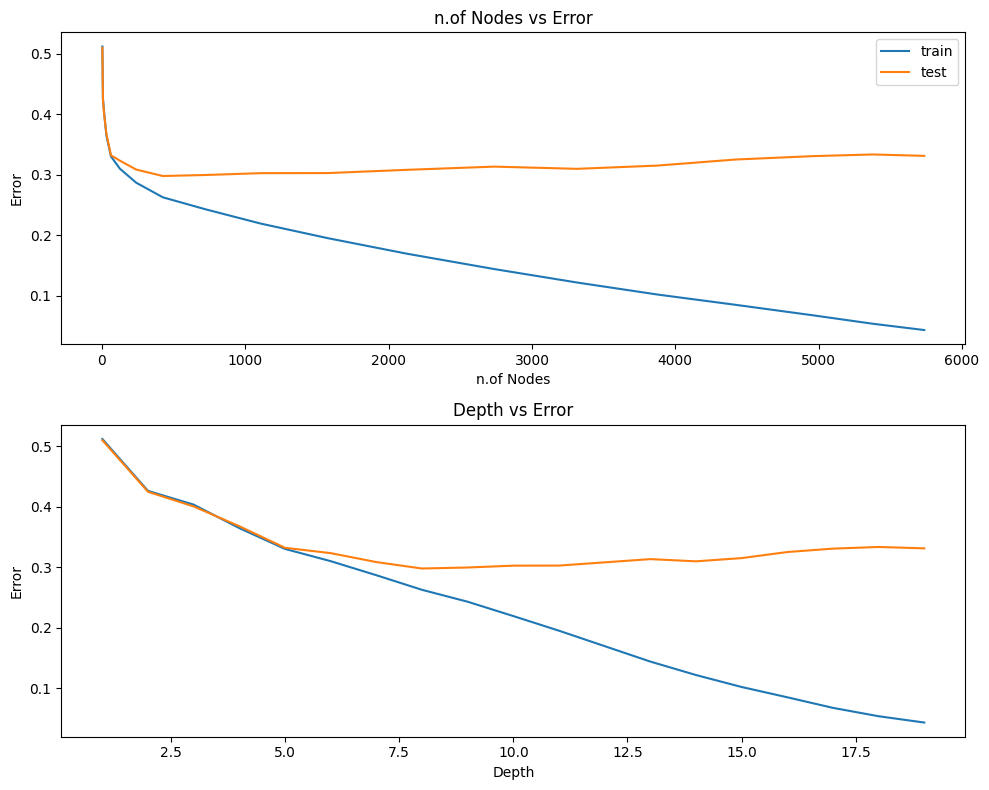

In [14]:
fig, ax = plt.subplots(2,1, figsize=(10, 8))
ax[0].plot(nodes, train_err, label='train')
ax[0].plot(nodes, test_err, label='test')
ax[0].legend()

ax[0].set_xlabel("n.of Nodes")
ax[0].set_ylabel("Error")
ax[0].set_title("n.of Nodes vs Error")

ax[1].plot(list(np.arange(1, 20)), train_err, label='train')
ax[1].plot(list(np.arange(1, 20)), test_err, label='test')

ax[1].set_xlabel("Depth")
ax[1].set_ylabel("Error")
ax[1].set_title("Depth vs Error")

plt.tight_layout()
plt.show()

## Hyperparameters

1) **max_depth** : int, default=None <br>
    The maximum depth of the tree. If None, then nodes are expanded until
    all leaves are pure or until all leaves contain less than
    min_samples_split samples.

2) **min_samples_split** : int or float, default=2 <br>
    The minimum number of samples required to split an internal node:

    - If int, then consider `min_samples_split` as the minimum number.
    - If float, then `min_samples_split` is a fraction and
      `ceil(min_samples_split * n_samples)` are the minimum
      number of samples for each split.

3) **min_samples_leaf** : int or float, default=1 <br>
    The minimum number of samples required to be at a leaf node.
    A split point at any depth will only be considered if it leaves at
    least ``min_samples_leaf`` training samples in each of the left and
    right branches.  This may have the effect of smoothing the model,
    especially in regression.

    - If int, then consider `min_samples_leaf` as the minimum number.
    - If float, then `min_samples_leaf` is a fraction and
      `ceil(min_samples_leaf * n_samples)` are the minimum
      number of samples for each node.

In [15]:
from sklearn.model_selection import cross_val_score

1) max_depth

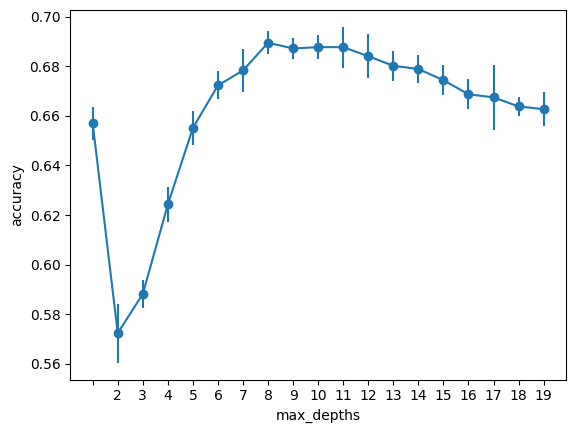

In [16]:
max_depths = [None] + list(np.arange(2, 20))
avg_scores = list()
std_scores = list()

# cross-validation to evaluate the effect of max_depth on model performance

for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth)
    scores = cross_val_score(dt, X_train, y_train, cv=5) # 5-fold cross-validation
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(max_depths)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(max_depths)), max_depths)
plt.xlabel("max_depths")
plt.ylabel("accuracy")
plt.show()

# max_depth=8 presents a good mean and variance trade-off

2) Min_samples_splits

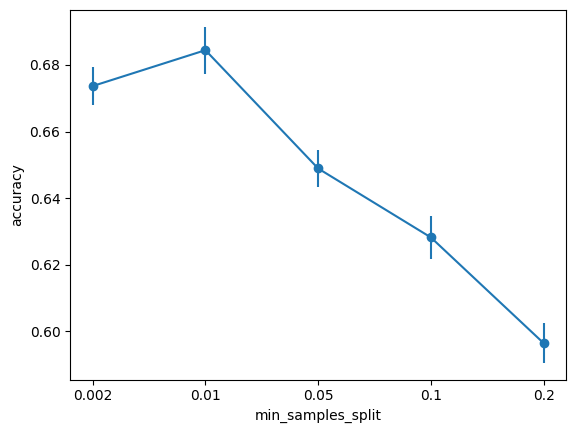

In [ ]:
min_samples_splits = [0.002, 0.01, 0.05, 0.1, 0.2] # min_samples_split as a fraction of the training set size
avg_scores = list()
std_scores = list()

# cross-validation to evaluate the effect of min_samples_split on model performance

for min_samples_split in min_samples_splits:
    dt = DecisionTreeClassifier(min_samples_split=min_samples_split)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_splits)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_splits)), min_samples_splits)
plt.xlabel("min_samples_split")
plt.ylabel("accuracy")
plt.show()

3) Min_samples_leaves

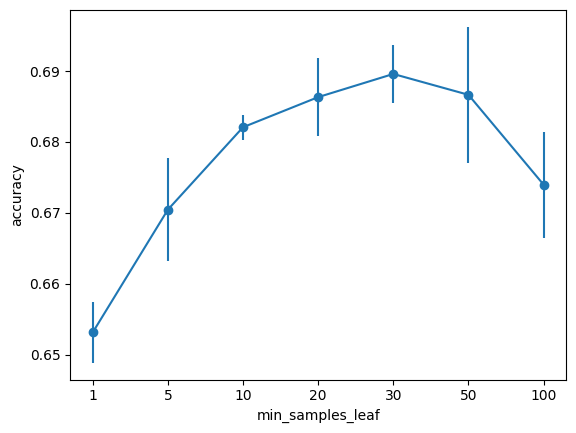

In [18]:
min_samples_leafs = [1, 5, 10, 20, 30, 50, 100]
avg_scores = list()
std_scores = list()

# cross-validation to evaluate the effect of min_samples_leaf on model performance

for min_samples_leaf in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=min_samples_leaf)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    avg_scores.append(np.mean(scores))
    std_scores.append(np.std(scores))

plt.errorbar(range(len(min_samples_leafs)), y=avg_scores, yerr=std_scores, marker='o')
plt.xticks(range(len(min_samples_leafs)), min_samples_leafs)
plt.xlabel("min_samples_leaf")
plt.ylabel("accuracy")
plt.show()

## Randomized Search
W.r.t. the Grid Search, which it's deterministic, the Randomized Search is not deterministic

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:
%%time
# hyperparameter tuning using Randomized Search with Cross-Validation
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [2, 5, 10, 20, 30, 50, 100],
    'min_samples_leaf': [1, 5, 10, 20, 30, 50, 100],
    'criterion': ['gini', 'entropy']
    # 'ccp_alpha': [0.0, 0.001, 0.01, 0.1] include this line if you want a score-complexity trade-off
}

clf = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=param_list, # define parameter space
    cv=RepeatedStratifiedKFold(random_state=0),
    #scoring=None, If None (default), the estimator’s score method is used (accuracy)
    n_jobs=-1,
    refit=True,
    n_iter=200,
    #verbose=2
)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_

CPU times: total: 2min 17s
Wall time: 5min 50s


In [ ]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 50, 'min_samples_leaf': 5, 'max_depth': 12, 'criterion': 'gini'} 0.6931831537708127


In [ ]:
y_test_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.6959171237050579


In [ ]:
clf.score(X_test, y_test)

0.6959171237050579

In [ ]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.956839699640875
Train F1-score [0.97933227 0.94685153 0.95294559]

Test Accuracy 0.6959171237050579
Test F1-score [0.69836957 0.73101904 0.66724952]


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.71      0.69      0.70      1500
         Low       0.71      0.75      0.73      2172
      Medium       0.67      0.66      0.67      2892

    accuracy                           0.70      6564
   macro avg       0.70      0.70      0.70      6564
weighted avg       0.70      0.70      0.70      6564



In [ ]:
results = pd.DataFrame(random_search.cv_results_)

<Axes: xlabel='param_max_depth', ylabel='mean_test_score'>

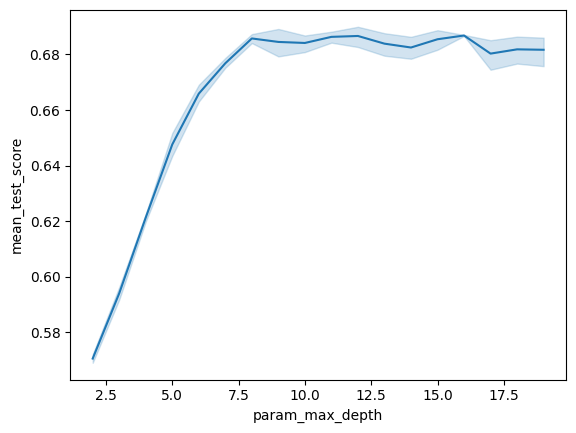

In [ ]:
# max_depth plot
sns.lineplot(data=results, x="param_max_depth", y="mean_test_score")

<Axes: xlabel='param_min_samples_leaf', ylabel='mean_test_score'>

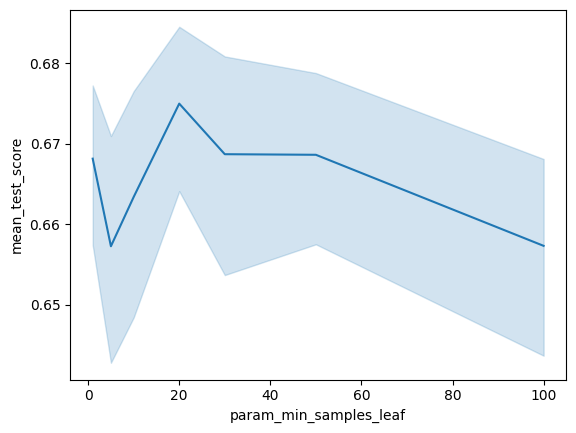

In [ ]:
# min_samples_leaf plot
sns.lineplot(data=results, x="param_min_samples_leaf", y="mean_test_score")

In [ ]:
# feature importance of the tuned classifier (i.e, the best estimator)
zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

YearPublished 0.24341410067062216
Rank 0.24096236853141206
GameWeight 0.21287406849706664
EngagementLevel 0.12445621367275979
MfgPlaytime 0.028894934680229526
MaxPlayers 0.022813076358360163
Category_Family 0.018554782722630603
Category_War 0.01334999196769207
Category_NoCategory 0.012572537376840491
Category_Thematic 0.012067857860088356
HasFamily 0.011865393924553679
MinPlayers 0.009754728109130023
NumExpansions 0.007228596110408103
Category_CGS 0.007125781090485064
MfgAgeRec 0.0065546609260615386
Category_Childrens 0.006351940468287871
NumAlternates 0.005502961415189904
NumImplementations 0.004530630323951099
Category_Party 0.004342724091907724
Category_Abstract 0.002977971914243429
Category_Strategy 0.0019007504693855843
IsReimplementation 0.001117589507030527
Kickstarted 0.000786339311663837


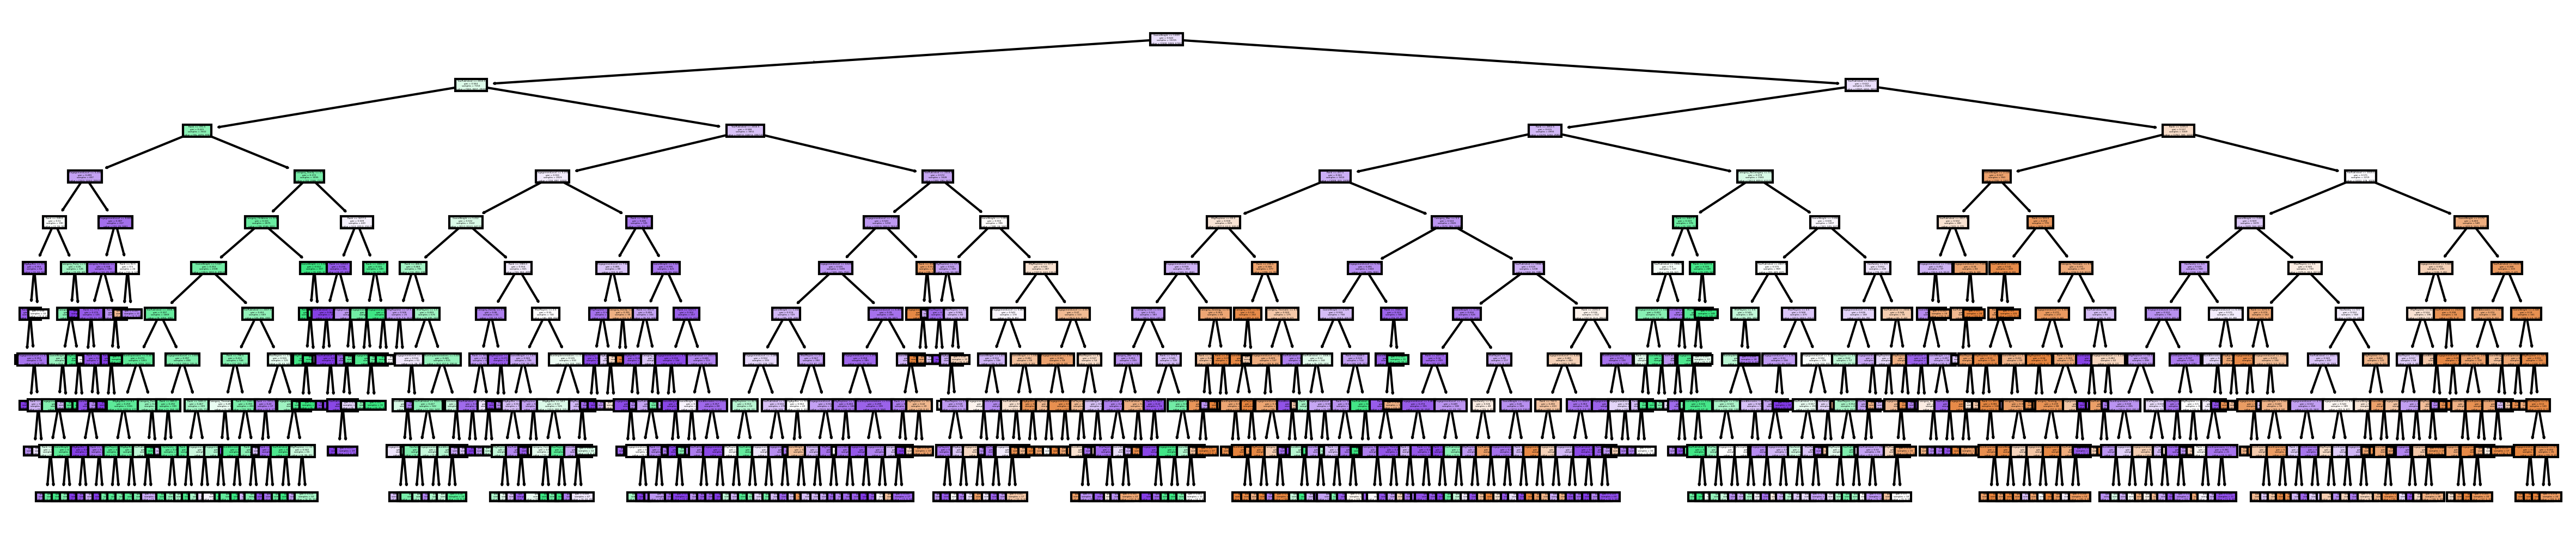

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True)
plt.show() # plot the best model found by RandomizedSearchCV

## Cost-complexity pruning 

In [ ]:
# ccp helps detecting how much impurity decreases if we prune the tree (impurity decrease -> prune)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
for alpha, imp in zip(ccp_alphas, impurities):
    print(alpha, imp) 

# impurity grows with increasing alpha -> the higher alpha, the more agressive the pruning (-> the impurity grows)

0.0 0.31926533328084744
3.6207642003173077e-06 0.31926895404504774
4.625794944005903e-06 0.3192735798399917
4.6680780398914335e-06 0.3192782479180316
8.70606159538585e-06 0.319286953979627
9.497521740420799e-06 0.3192964515013674
1.2043109872933959e-05 0.31932053772111324
1.454953228576707e-05 0.319335087253399
1.5170757750705287e-05 0.3193502580111497
1.5404211097469478e-05 0.31936566222224716
1.6027067936959986e-05 0.3193816892901841
1.9186632946920545e-05 0.31940087592313104
2.0201355109461224e-05 0.3194210772782405
2.0681820532025233e-05 0.3194417590987725
2.15515977907255e-05 0.3194848622943539
2.3586414091686532e-05 0.3195084487084456
2.3630738616047206e-05 0.3195557101856777
2.534208347959474e-05 0.3195810522691573
2.9146380123682607e-05 0.319610198649281
3.1008887544668685e-05 0.3196412075368256
3.4162683307960035e-05 0.3196753702201336
3.65206480894673e-05 0.31971189086822305
3.683587425017403e-05 0.31974872674247323
3.9567851597698944e-05 0.31978829459407093
4.363456464587679

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

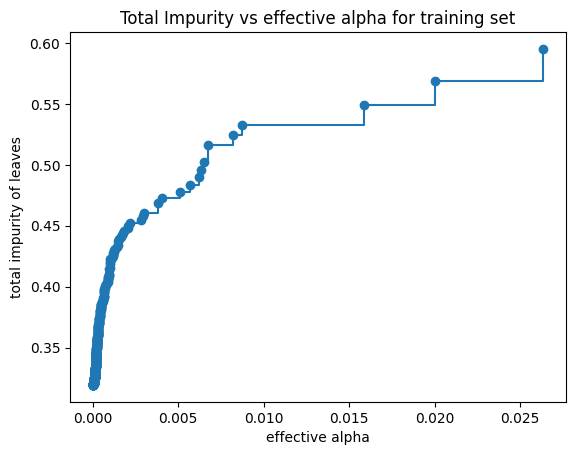

In [ ]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [ ]:
random_search.best_params_

{'min_samples_split': 50,
 'min_samples_leaf': 5,
 'max_depth': 12,
 'criterion': 'gini'}

In [ ]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha, **random_search.best_params_)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
))

NameError: name 'ccp_alphas' is not defined

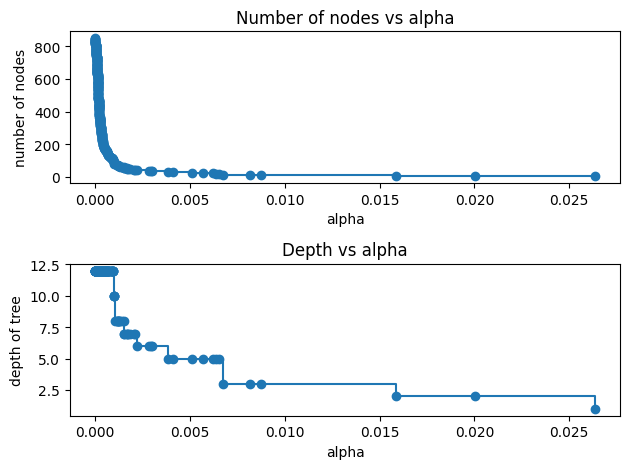

In [ ]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

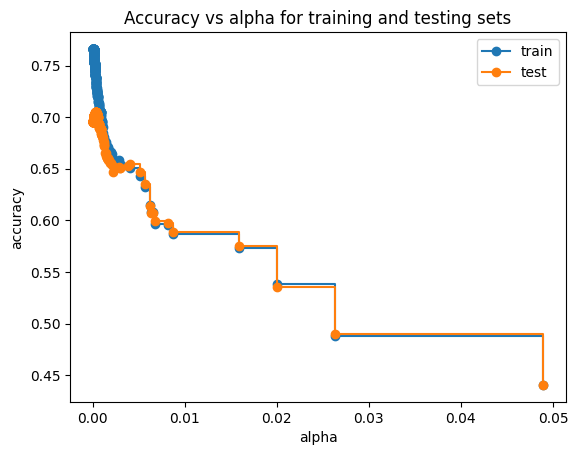

Best alpha:  0.00035917285070044373


In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

# plot alpha vs accuracy for training and testing sets

print("Best alpha: ", ccp_alphas[np.argmax(test_scores)])

In [ ]:
dtp = DecisionTreeClassifier(ccp_alpha= 0.00035917285070044373, **random_search.best_params_) # best alpha from the plot
dtp.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,12
,min_samples_split,50
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_test_pred = dtp.predict(X_test)

NameError: name 'dtp' is not defined

In [ ]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.956839699640875
Train F1-score [0.97933227 0.94685153 0.95294559]

Test Accuracy 0.70551492992078
Test F1-score [0.69630156 0.74725747 0.6758426 ]


In [ ]:
y_test_pred = dtp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.70551492992078


In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.75      0.65      0.70      1500
         Low       0.70      0.80      0.75      2172
      Medium       0.69      0.66      0.68      2892

    accuracy                           0.71      6564
   macro avg       0.71      0.70      0.71      6564
weighted avg       0.71      0.71      0.70      6564



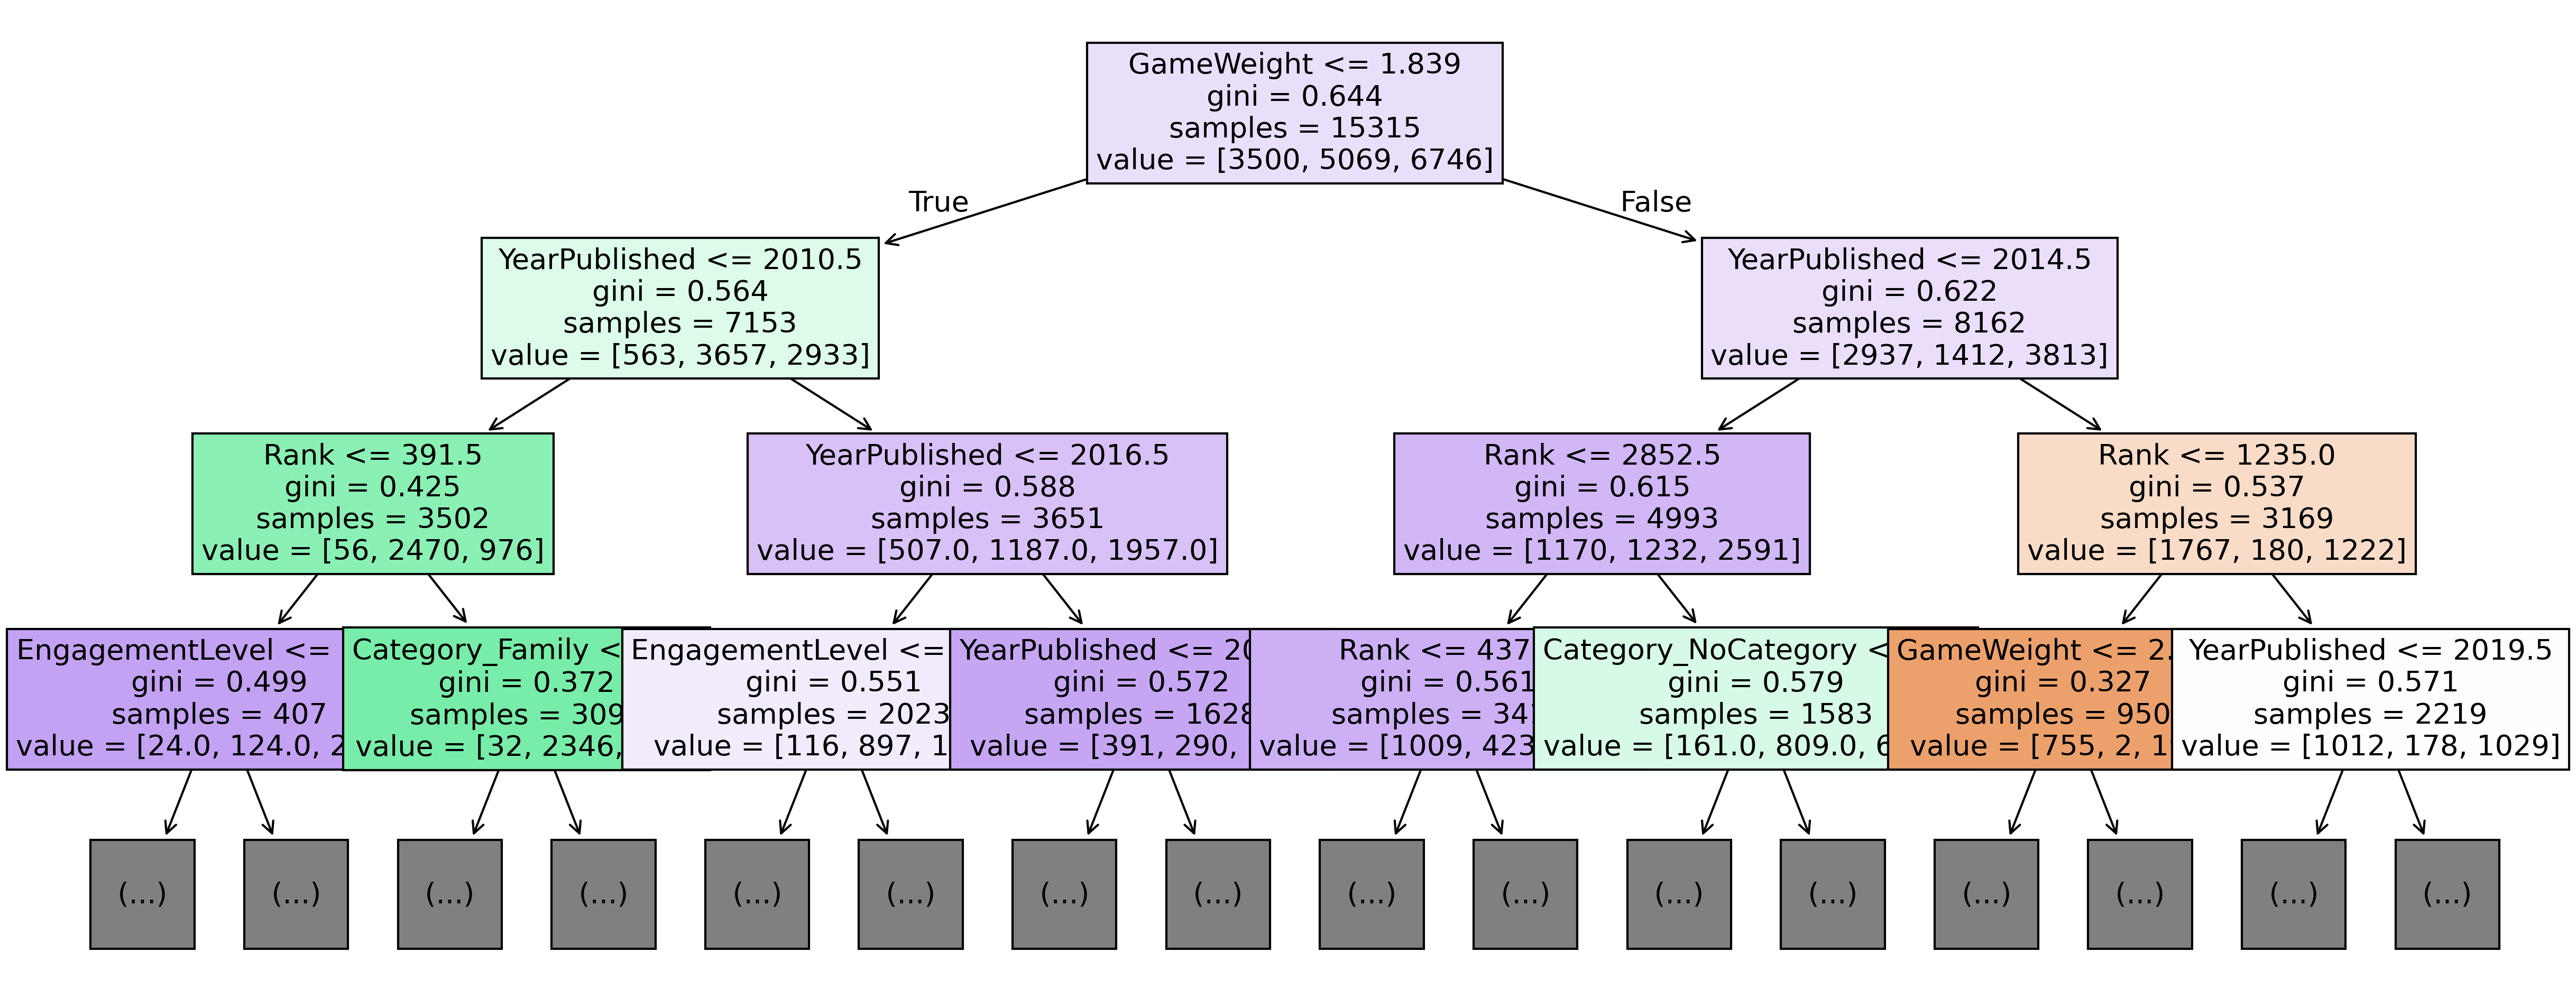

In [ ]:
plt.figure(figsize=(20, 8), dpi=300)
plot_tree(dtp, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()

## ROC Curve

In [ ]:
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall

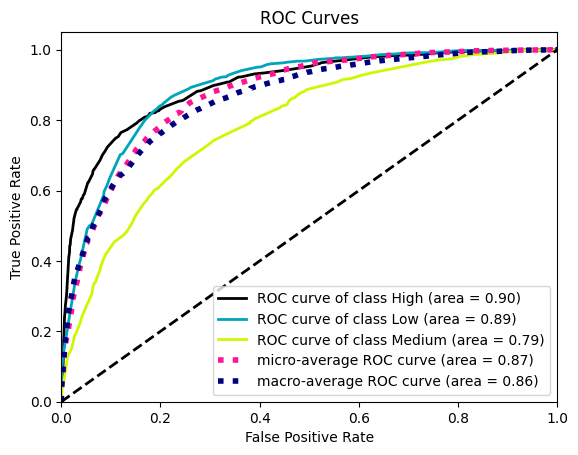

In [ ]:
plot_roc(y_test, dtp.predict_proba(X_test))
plt.show()

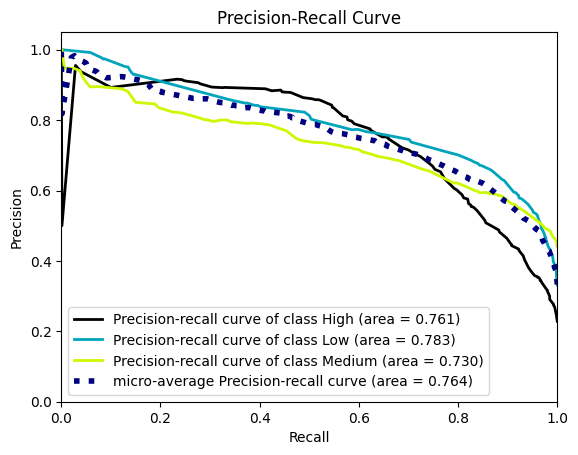

In [ ]:
plot_precision_recall(y_test, dtp.predict_proba(X_test))
plt.show()

## Post-pruning

In [ ]:
from sklearn.tree._tree import TREE_LEAF

In [ ]:
# this functions check if some splits lead to the same classification decision

# check whether node is leaf node
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)

# recursively prune tree
def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))

# main function to prune duplicate leaves
def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [ ]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


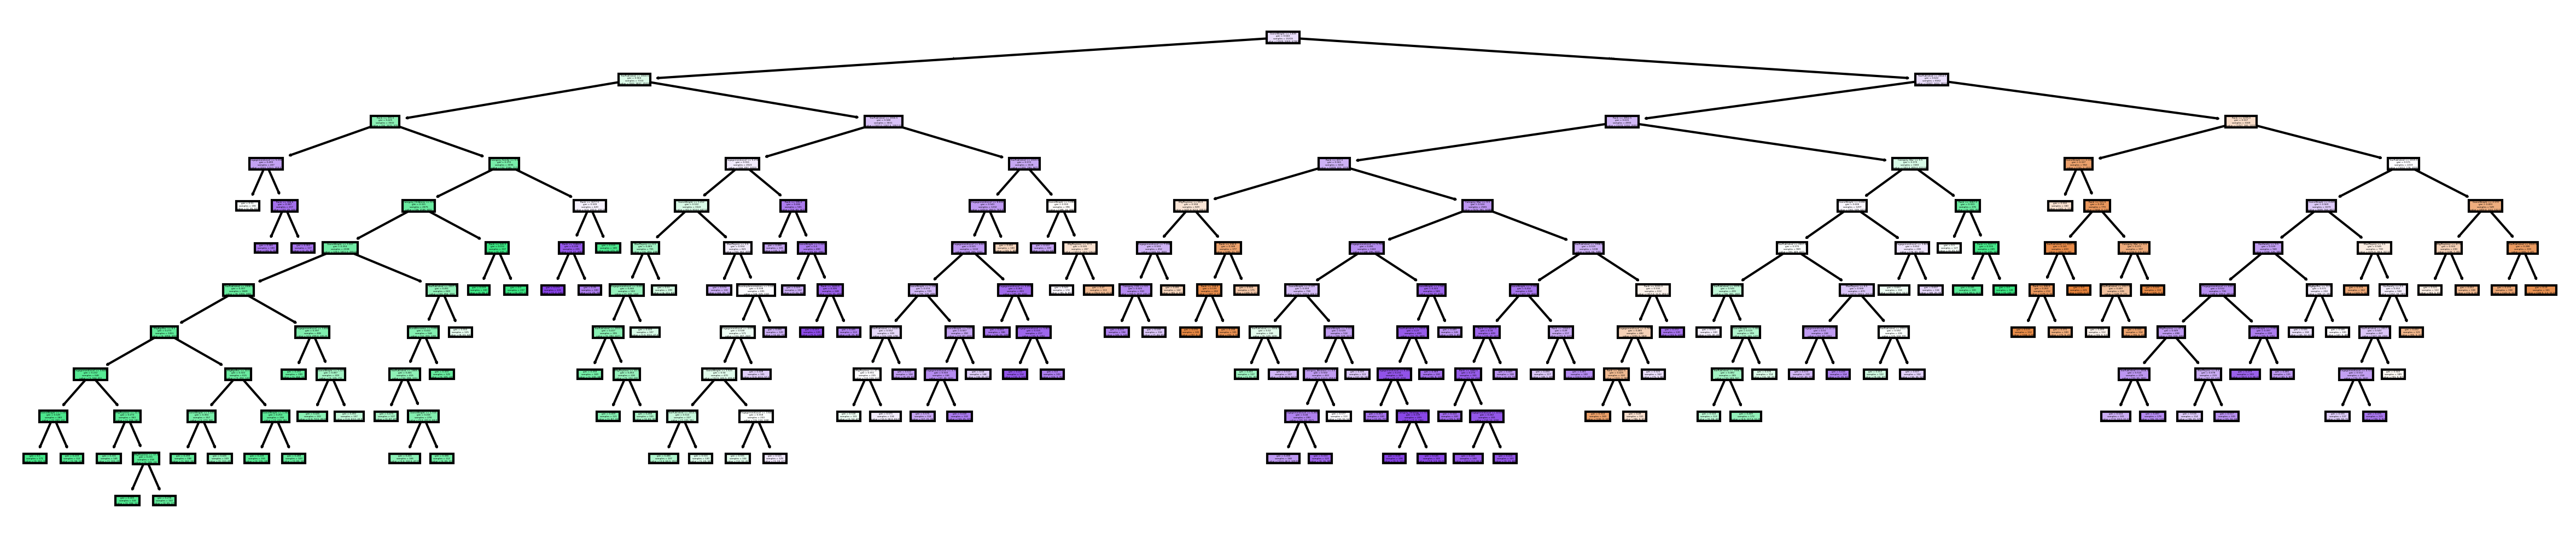

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True)
plt.show()

In [ ]:
prune_duplicate_leaves(dt) # prune duplicate leaves

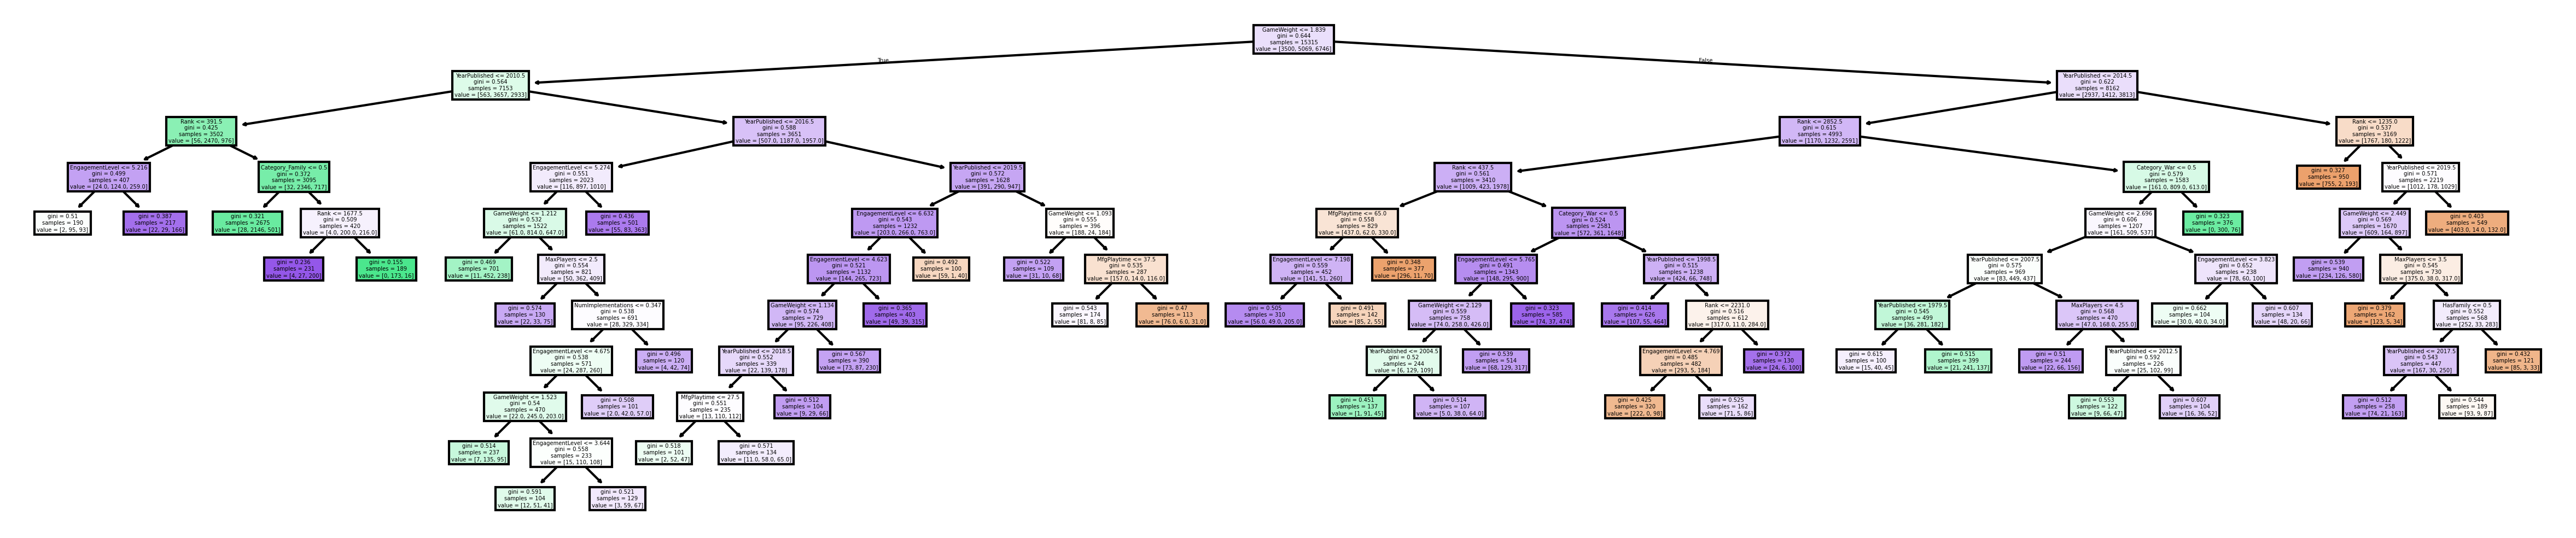

In [ ]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dt, feature_names=attributes, filled=True)
plt.show()

## Defining a balanced decision tree

Due to the fact that the model optimizes only the accuracy in the Randomized Search, it lacks in classifying medium. So, we optimize `balanced_accuracy` to have an accuracy weighted for all the classes.

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

In [45]:
%%time
# hyperparameter tuning using Randomized Search with Cross-Validation
param_list = {
    'max_depth': [None] + list(np.arange(2, 20)),
    'min_samples_split': [2, 5, 10, 20, 30, 50, 100],
    'min_samples_leaf': [1, 5, 10, 20, 30, 50, 100],
    'criterion': ['gini', 'entropy']
    # 'ccp_alpha': [0.0, 0.001, 0.01, 0.1] include this line if you want a score-complexity trade-off
}

clf = DecisionTreeClassifier(criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1)

random_search = RandomizedSearchCV( 
    DecisionTreeClassifier(),
    param_distributions=param_list, # define parameter space
    cv=RepeatedStratifiedKFold(random_state=0, n_splits=10, n_repeats=10),
    scoring='balanced_accuracy',
    n_jobs=-1,
    refit=True,
    n_iter=200, # number of samples to draw
    #verbose=2
)

random_search.fit(X_train, y_train)
clf = random_search.best_estimator_

CPU times: total: 1min 29s
Wall time: 4min 38s


In [46]:
# hyperparameter tuning after pruning
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 30, 'min_samples_leaf': 1, 'max_depth': 11, 'criterion': 'gini'} 0.6942529305662175


In [47]:
from sklearn.metrics import balanced_accuracy_score
y_train_pred = clf.predict(X_train)
print("Balanced Accuracy on training set:", balanced_accuracy_score(y_train, y_train_pred))

Balanced Accuracy on training set: 0.7693258566769337


In [48]:
y_test_pred = clf.predict(X_test)
print("Balanced Accuracy on test set:", balanced_accuracy_score(y_test, y_test_pred))

Balanced Accuracy on test set: 0.6992953088344299


In [49]:
clf.score(X_test, y_test)

0.6994210847044485

In [50]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print("Error on training set:", 1 - accuracy_score(y_train, y_train_pred))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))
print("Error on test set:", 1 - accuracy_score(y_test, y_test_pred))

Train Accuracy 0.7730329742082925
Train F1-score [0.76760351 0.79900029 0.75582335]
Error on training set: 0.22696702579170747

Test Accuracy 0.6994210847044485
Test F1-score [0.70055325 0.72837838 0.67667357]
Error on test set: 0.3005789152955515


In [51]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.73      0.68      0.70      1500
         Low       0.71      0.74      0.73      2172
      Medium       0.68      0.68      0.68      2892

    accuracy                           0.70      6564
   macro avg       0.71      0.70      0.70      6564
weighted avg       0.70      0.70      0.70      6564



In [52]:
results = pd.DataFrame(random_search.cv_results_)

<Axes: xlabel='param_max_depth', ylabel='mean_test_score'>

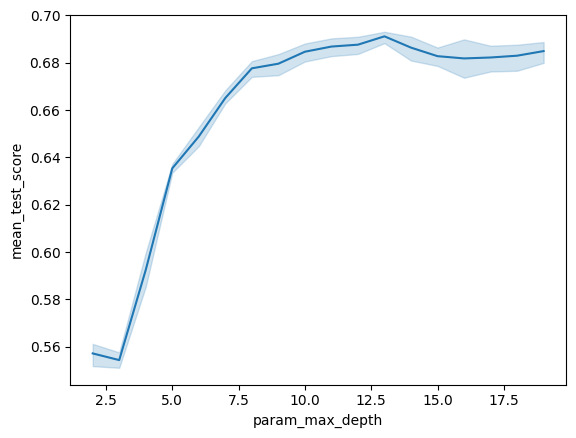

In [53]:
# max_depth plot
sns.lineplot(data=results, x="param_max_depth", y="mean_test_score")

<Axes: xlabel='param_min_samples_leaf', ylabel='mean_test_score'>

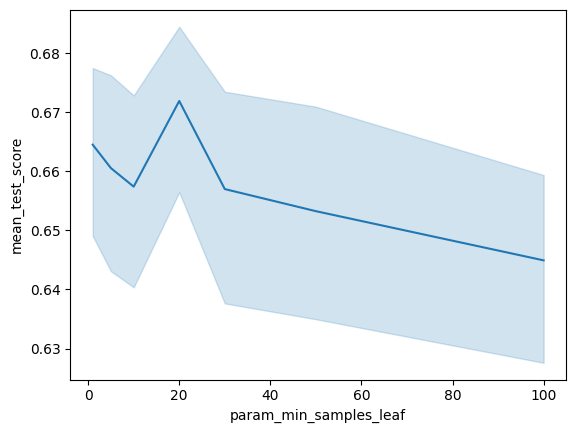

In [54]:
# min_samples_leaf plot
sns.lineplot(data=results, x="param_min_samples_leaf", y="mean_test_score")

In [55]:
# feature importance of the tuned classifier (i.e, the best estimator)
zipped = zip(attributes, clf.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

YearPublished 0.23904935615246575
Rank 0.23409754060137536
GameWeight 0.21245453034630815
EngagementLevel 0.12064242224349309
MfgPlaytime 0.027319474178882332
MaxPlayers 0.024705039249209186
Category_Family 0.020255764614236327
Category_War 0.01412079382867416
HasFamily 0.012503975005205769
Category_Thematic 0.012502674855071446
Category_NoCategory 0.012357359655787459
MinPlayers 0.011262544173771382
MfgAgeRec 0.009183388236024721
NumExpansions 0.009059783253795264
NumAlternates 0.008537205626562286
Category_CGS 0.007355845564297164
Category_Childrens 0.0062432276418103415
NumImplementations 0.0053013289270779805
Category_Party 0.004268398802966437
Category_Abstract 0.0042165514957135525
Category_Strategy 0.002298004783723967
Kickstarted 0.0014322379130975564
IsReimplementation 0.0008325528504503838


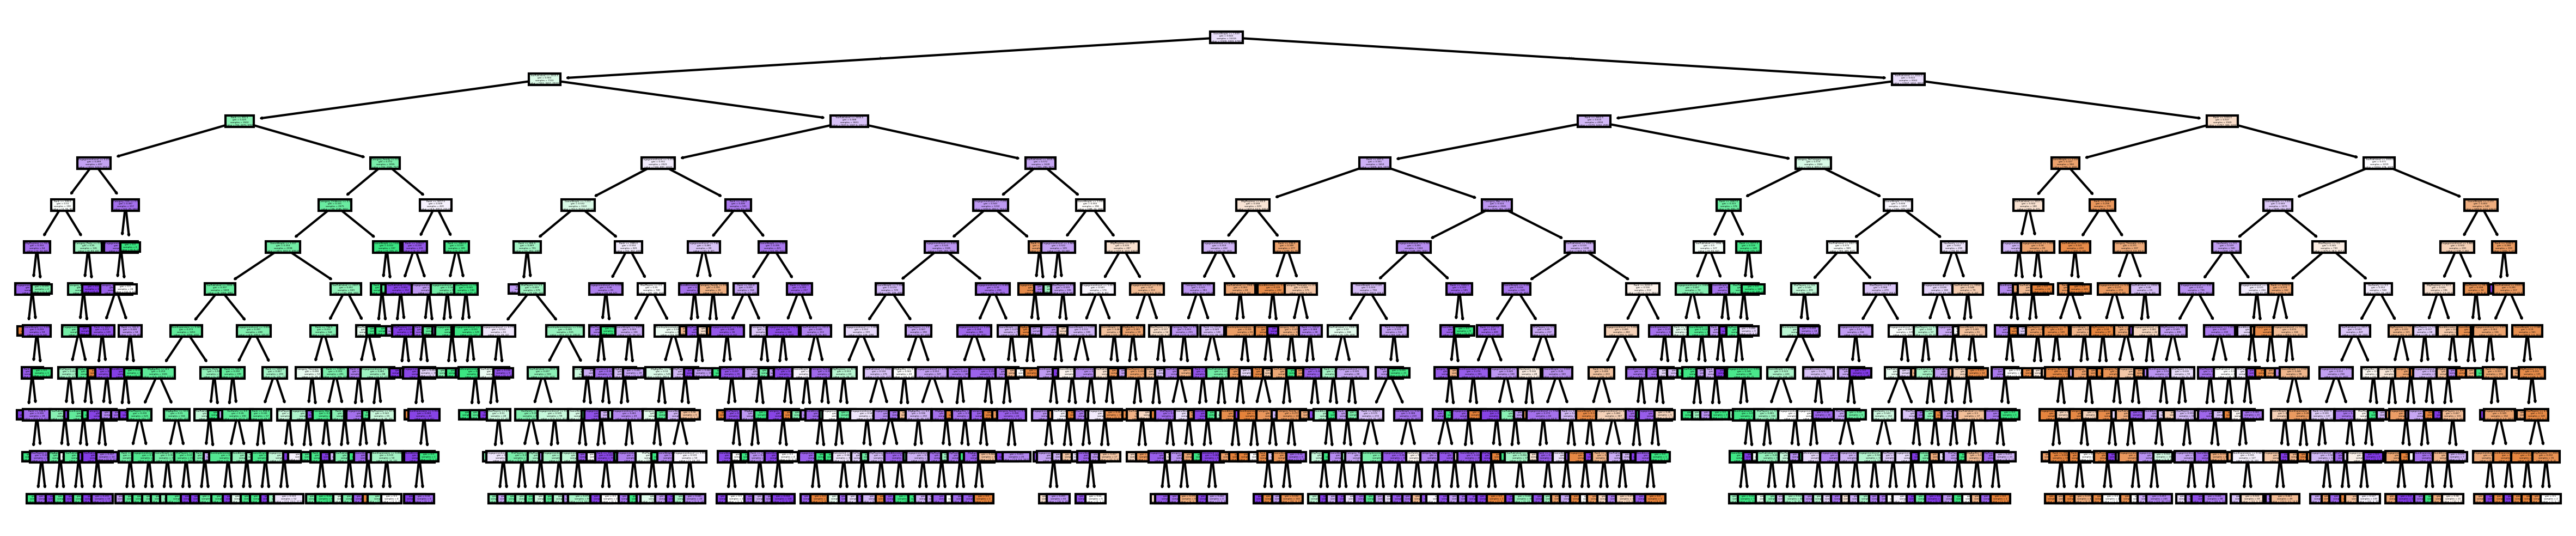

In [56]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(clf, feature_names=attributes, filled=True)
plt.show() # plot the best model found by RandomizedSearchCV

## Post-pruning 1: Cost-complexity pruning 

In [57]:
# ccp helps detecting how much impurity decreases if we prune the tree (impurity decrease -> prune)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [58]:
for alpha, imp in zip(ccp_alphas, impurities):
    print(alpha, imp) 

# impurity grows with increasing alpha -> the higher alpha, the more agressive the pruning (-> the impurity grows)

0.0 0.31354064347756616
4.625794944005903e-06 0.31354526927251014
9.679092008987574e-06 0.31355494836451914
1.3489861065767061e-05 0.3135684382255849
1.5170757750705287e-05 0.3135836089833356
2.2853411687887603e-05 0.3136064623950235
2.3008877073519546e-05 0.313629471272097
2.481027534549578e-05 0.31367909182278797
2.534208347959474e-05 0.31370443390626757
2.911824655213502e-05 0.31373355215281973
2.9146380123682607e-05 0.3137626985329434
3.070690775939372e-05 0.3138241123484622
3.172807658881784e-05 0.313855840425051
3.490339239604678e-05 0.313890743817447
3.8048412849237326e-05 0.31392879223029624
3.837922153299226e-05 0.31396717145182923
3.944934160409185e-05 0.31400662079343333
5.093222269365329e-05 0.314057553016127
5.402879401842357e-05 0.3141656106041638
5.432808566990739e-05 0.3142199386898337
5.482077766209929e-05 0.31427475946749583
5.543100547997687e-05 0.31433019047297583
5.5505128962524055e-05 0.31438569560193835
5.882942828898917e-05 0.31444452503022735
5.912866833532901e

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

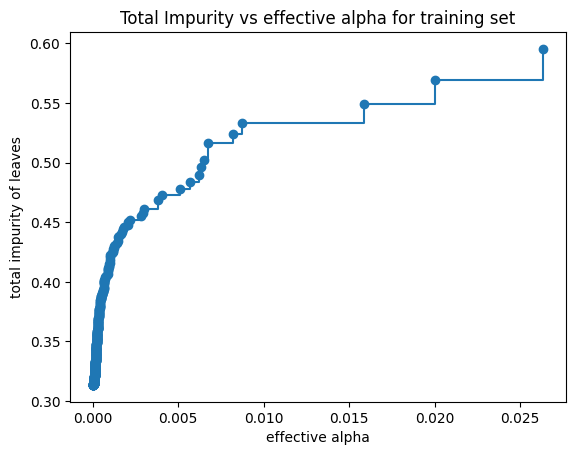

In [59]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [60]:
random_search.best_params_

{'min_samples_split': 30,
 'min_samples_leaf': 1,
 'max_depth': 11,
 'criterion': 'gini'}

In [61]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha, **random_search.best_params_)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.048965422131777125


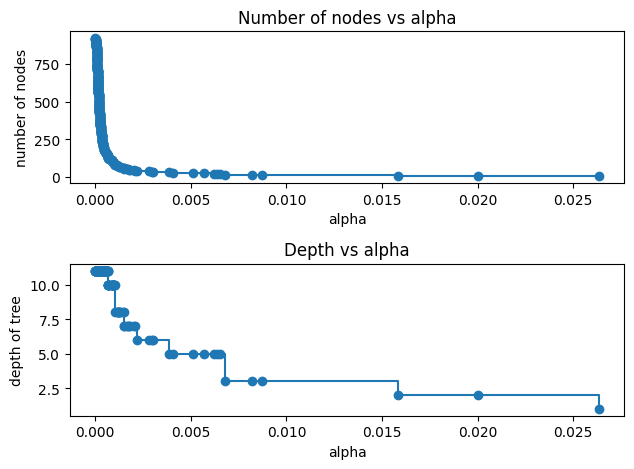

In [62]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

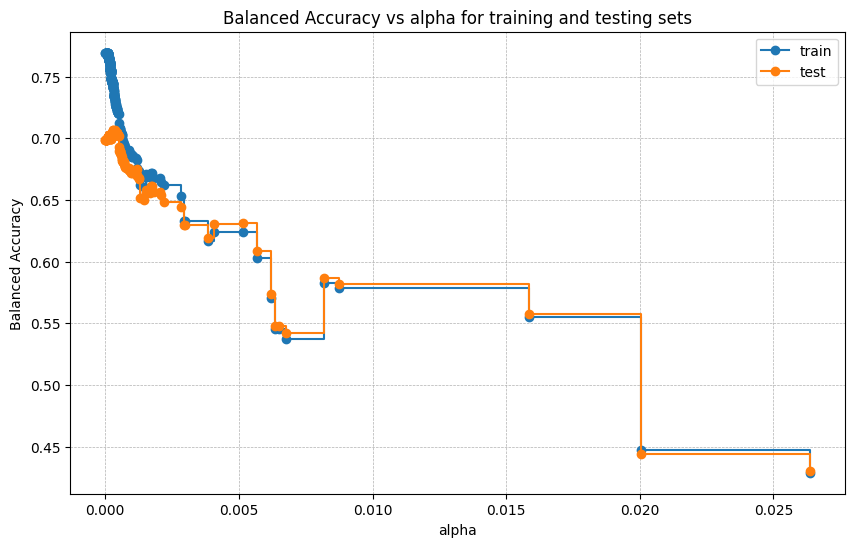

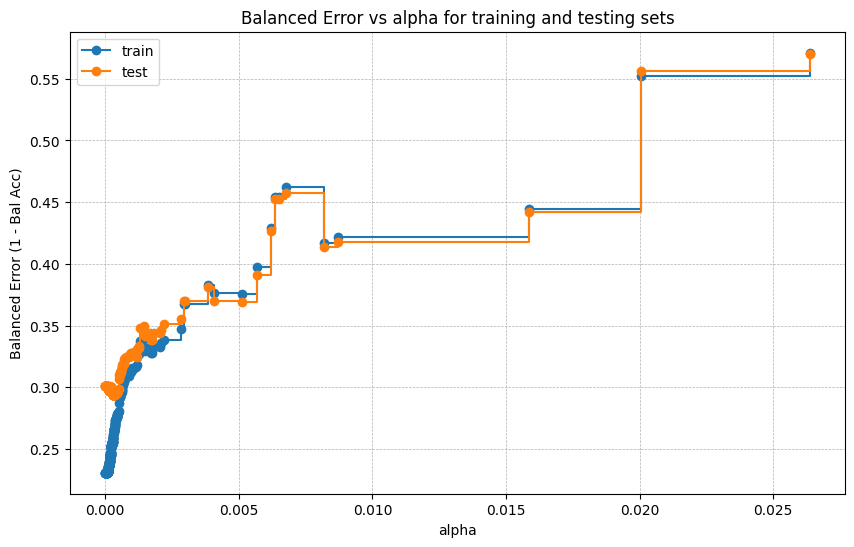

Best alpha (max Balanced Accuracy): 0.000291
Max Test Balanced Accuracy obtained: 0.7064


In [63]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import balanced_accuracy_score

# --- CALCOLO DEGLI SCORE ---
# Invece di clf.score() (che è l'accuracy normale), usiamo balanced_accuracy_score
# Dobbiamo prima fare la predizione (.predict) e poi confrontarla con le y vere
train_scores = [balanced_accuracy_score(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [balanced_accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

# --- PLOT 1: BALANCED ACCURACY VS ALPHA ---
fig, ax = plt.subplots(figsize=(10, 6)) # Aumentato un po' la dimensione per leggibilità
ax.set_xlabel("alpha")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Balanced Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5) # Aggiunge una griglia per leggere meglio i valori
plt.show()

# --- PLOT 2: ERROR VS ALPHA ---
# Qui calcoliamo l'errore come "1 - Balanced Accuracy"
train_error = [1 - score for score in train_scores]
test_error = [1 - score for score in test_scores]

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("alpha")
ax.set_ylabel("Balanced Error (1 - Bal Acc)")
ax.set_title("Balanced Error vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_error, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_error, marker="o", label="test", drawstyle="steps-post")
ax.legend()
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

# --- TROVA IL MIGLIOR ALPHA ---
# Cerchiamo l'indice del valore più alto nella lista dei test_scores
best_index = np.argmax(test_scores)
best_alpha = ccp_alphas[best_index]
best_score = test_scores[best_index]

print(f"Best alpha (max Balanced Accuracy): {best_alpha:.6f}")
print(f"Max Test Balanced Accuracy obtained: {best_score:.4f}")

# Opzionale: Se vuoi vedere anche l'accuratezza standard a quel livello per confronto
# best_clf = clfs[best_index]
# print(f"Standard Accuracy at this alpha: {best_clf.score(X_test, y_test):.4f}")

In [64]:
dtp = DecisionTreeClassifier(ccp_alpha= best_alpha, **random_search.best_params_) # best alpha from the plot
dtp.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,11
,min_samples_split,30
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_test_pred = dtp.predict(X_test)
y_train_pred = dtp.predict(X_train)

In [66]:
print('Train Balanced Accuracy %s' % balanced_accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print('Train error %s' % (1 - balanced_accuracy_score(y_train, y_train_pred)))
print()

print('Test Balanced Accuracy %s' % balanced_accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))
print('Test error %s' % (1 - balanced_accuracy_score(y_test, y_test_pred)))

Train Balanced Accuracy 0.7418852427858337
Train F1-score [0.73815907 0.77570359 0.71705455]
Train error 0.2581147572141663

Test Balanced Accuracy 0.7064234250068138
Test F1-score [0.70697996 0.74026549 0.67518376]
Test error 0.29357657499318623


In [67]:
y_test_pred = dtp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_test_pred))

Accuracy: 0.7046008531383303


In [68]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

        High       0.73      0.68      0.71      1500
         Low       0.71      0.77      0.74      2172
      Medium       0.68      0.67      0.68      2892

    accuracy                           0.70      6564
   macro avg       0.71      0.71      0.71      6564
weighted avg       0.70      0.70      0.70      6564



In [69]:
# feature importance of the pruned tuned classifier
zipped = zip(attributes, dtp.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Rank 0.27146769256051834
YearPublished 0.2614904056244344
GameWeight 0.23000821899816062
EngagementLevel 0.10419945438233434
MfgPlaytime 0.020940924258072403
Category_Family 0.01779210974427676
Category_War 0.015270233806984229
MaxPlayers 0.015108614191222142
Category_Thematic 0.013005680450044335
HasFamily 0.012514736895528936
Category_CGS 0.007486142196378515
Category_Childrens 0.0072655935908828235
Category_Abstract 0.004600052987662796
Category_Party 0.0038916784203020197
NumImplementations 0.0037871399990779013
MinPlayers 0.0034738576552758743
MfgAgeRec 0.002441177106845118
NumExpansions 0.0021378973285633156
Category_Strategy 0.001962453138610934
NumAlternates 0.0011559366648242334
IsReimplementation 0.0
Kickstarted 0.0
Category_NoCategory 0.0


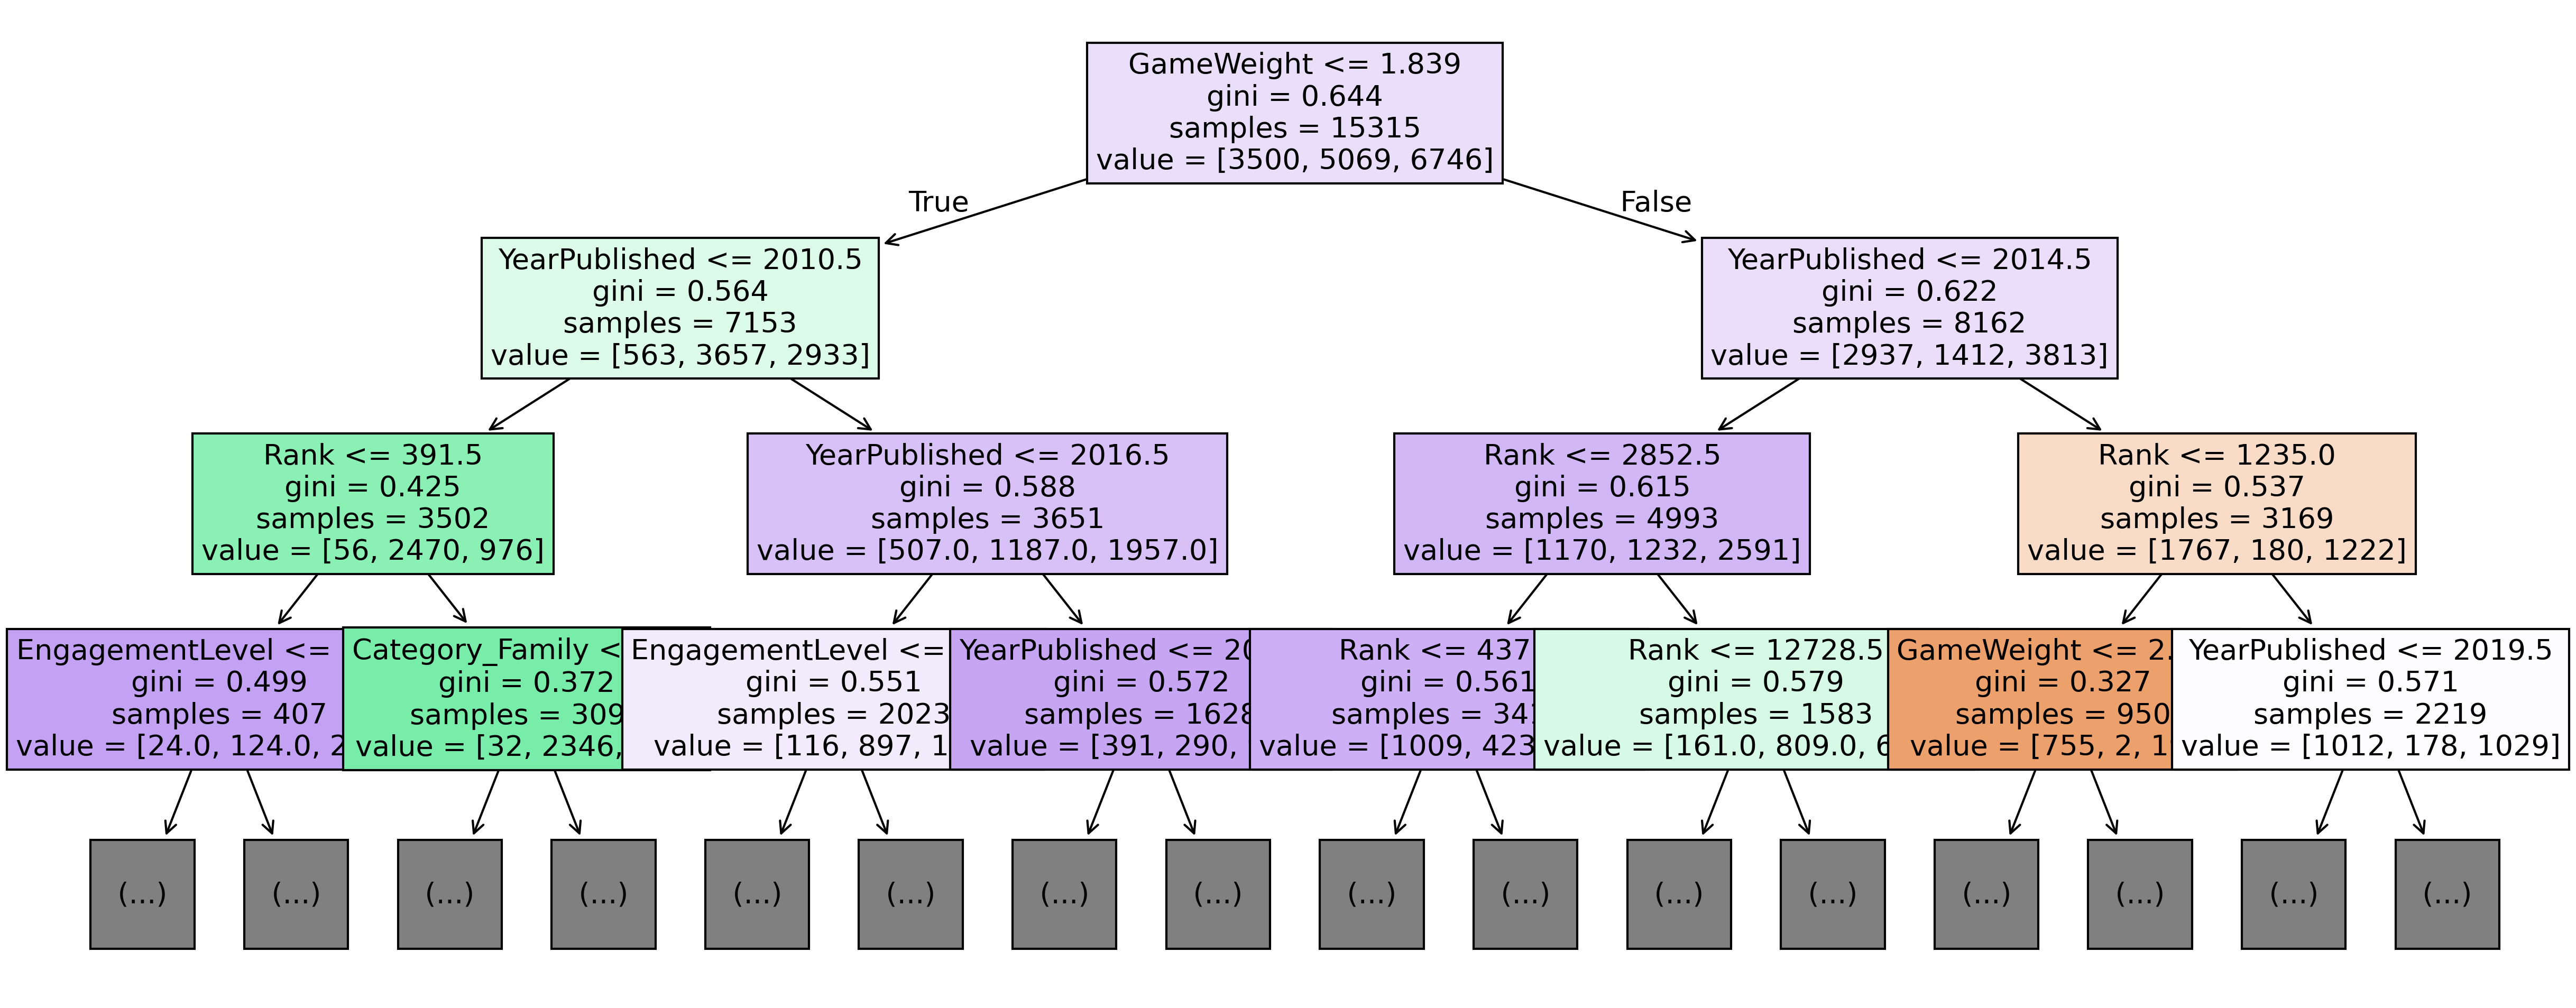

In [70]:
plt.figure(figsize=(20, 8), dpi=300)
plot_tree(dtp, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()

c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


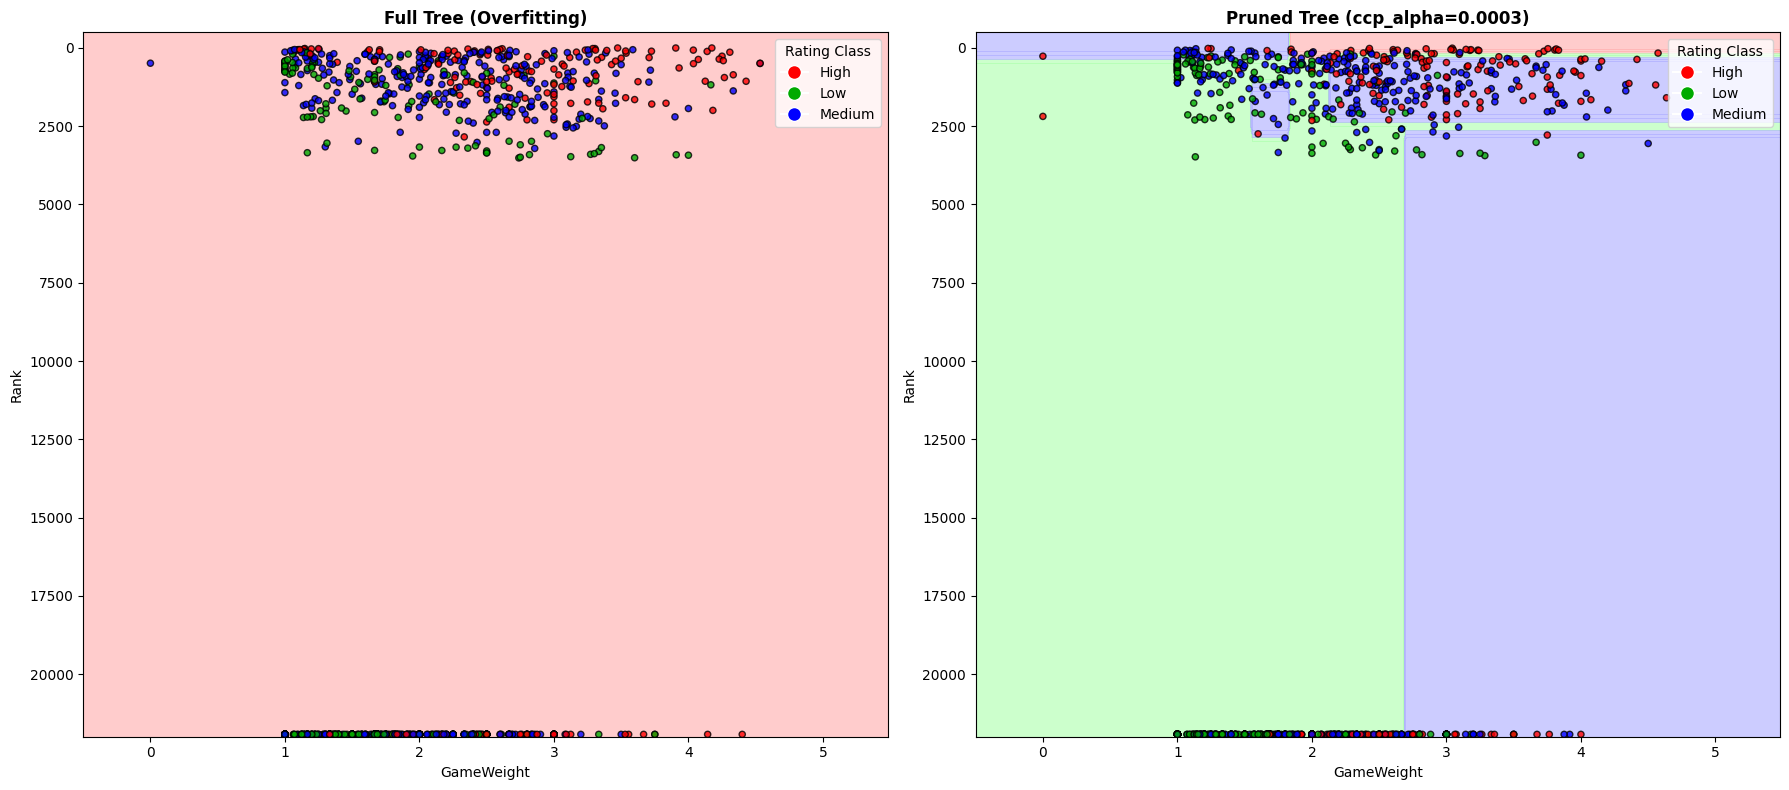

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 0. CONFIGURAZIONE PRELIMINARE
# ==========================================
# Assicuriamoci che l'encoder conosca tutte le classi
le = LabelEncoder()
le.fit(y_train) # Addestra l'encoder sulle classi originali (High, Medium, Low)
y_vis_enc = le.transform(y_train) # Trasforma y per lo scatter plot
class_names = le.classes_

# Indici delle feature (adatta se necessario)
idx_weight = X_train.columns.get_loc('GameWeight')
idx_rank = X_train.columns.get_loc('Rank')
feature_indices = [idx_weight, idx_rank]
feature_names_plot = ['GameWeight', 'Rank']

# ==========================================
# 1. FUNZIONE DI PLOTTING CORRETTA
# ==========================================
def plot_boundaries_slice(clf, X, y_encoded, ax, title, feat_idx, feat_names, encoder):
    # X deve essere passato come numpy array completo
    
    # 1. Creiamo la griglia
    h_x = 0.02  # Step GameWeight
    h_y = 500    # Step Rank
    
    x_min, x_max = X[:, feat_idx[0]].min() - 0.5, X[:, feat_idx[0]].max() + 0.5
    y_min, y_max = X[:, feat_idx[1]].min() - 500, X[:, feat_idx[1]].max() + 500
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h_x),
                         np.arange(y_min, y_max, h_y))

    # 2. Dataset fittizio (Slicing)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    n_samples_grid = grid_points.shape[0]
    
    # Riempiamo con la media
    X_background = np.tile(np.mean(X, axis=0), (n_samples_grid, 1))
    
    # Sovrascriviamo le due colonne attive
    X_background[:, feat_idx[0]] = grid_points[:, 0]
    X_background[:, feat_idx[1]] = grid_points[:, 1]
    
    # 3. PREDIZIONE
    Z_labels = clf.predict(X_background) # Qui otteniamo ['High', 'Low', ...]
    
    # --- ### CORREZIONE QUI ### ---
    # Convertiamo le stringhe predette in numeri (0, 1, 2)
    # Altrimenti contourf crasha
    Z_numeric = encoder.transform(Z_labels) 
    Z = Z_numeric.reshape(xx.shape)
    # ------------------------------

    # 4. PLOT
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00AA00', '#0000FF']

    # Ora Z contiene numeri, quindi contourf funziona
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    # Scatter plot dei punti reali
    sample_idx = np.random.choice(np.arange(len(X)), size=min(len(X), 1000), replace=False)
    
    # y_encoded deve essere già numerico
    scatter = ax.scatter(X[sample_idx, feat_idx[0]], X[sample_idx, feat_idx[1]], 
                         c=y_encoded[sample_idx], 
                         cmap=ListedColormap(cmap_bold), 
                         edgecolor='k', s=20, alpha=0.8)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.invert_yaxis() 
    
    # Legenda
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, label=l) 
               for c, l in zip(cmap_bold, class_names)]
    ax.legend(handles=handles, title="Rating Class")

# ==========================================
# 2. ESECUZIONE
# ==========================================
X_train_np = X_train.values if hasattr(X_train, 'values') else X_train

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Nota: passiamo 'le' (l'encoder) alla funzione
plot_boundaries_slice(clf, X_train_np, y_vis_enc, axes[0], 
                      "Full Tree (Overfitting)", 
                      feature_indices, feature_names_plot, le)

# Sostituisci 'dtp' con il nome del tuo modello potato
plot_boundaries_slice(dtp, X_train_np, y_vis_enc, axes[1], 
                      f"Pruned Tree (ccp_alpha={best_alpha:.4f})", 
                      feature_indices, feature_names_plot, le)

plt.tight_layout()
plt.show()

## ROC Curve

In [85]:
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall

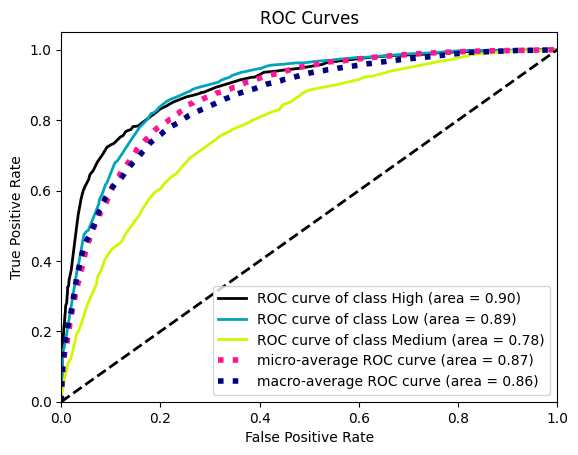

In [86]:
plot_roc(y_test, dtp.predict_proba(X_test))
plt.show()

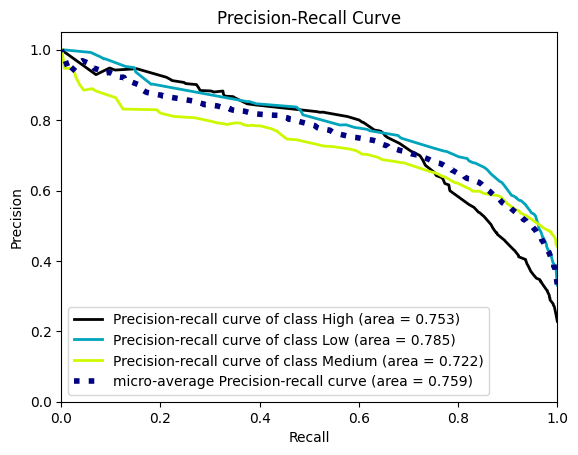

In [87]:
plot_precision_recall(y_test, dtp.predict_proba(X_test))
plt.show()

## Post-pruning 2: duplicated subtrees

In [88]:
from sklearn.tree._tree import TREE_LEAF

In [89]:
# this functions check if some splits lead to the same classification decision

# check whether node is leaf node
def is_leaf(inner_tree, index):
    # Check whether node is leaf node
    return (inner_tree.children_left[index] == TREE_LEAF and
            inner_tree.children_right[index] == TREE_LEAF)

# recursively prune tree
def prune_index(inner_tree, decisions, index=0):
    # Start pruning from the bottom - if we start from the top, we might miss
    # nodes that become leaves during pruning.
    # Do not use this directly - use prune_duplicate_leaves instead.
    if not is_leaf(inner_tree, inner_tree.children_left[index]):
        prune_index(inner_tree, decisions, inner_tree.children_left[index])
    if not is_leaf(inner_tree, inner_tree.children_right[index]):
        prune_index(inner_tree, decisions, inner_tree.children_right[index])

    # Prune children if both children are leaves now and make the same decision:
    if (is_leaf(inner_tree, inner_tree.children_left[index]) and
        is_leaf(inner_tree, inner_tree.children_right[index]) and
        (decisions[index] == decisions[inner_tree.children_left[index]]) and
        (decisions[index] == decisions[inner_tree.children_right[index]])):
        # turn node into a leaf by "unlinking" its children
        inner_tree.children_left[index] = TREE_LEAF
        inner_tree.children_right[index] = TREE_LEAF
        # print("Pruned {}".format(index))

# main function to prune duplicate leaves
def prune_duplicate_leaves(dt):
    # Remove leaves if both
    decisions = dt.tree_.value.argmax(axis=2).flatten().tolist()  # Decision for each node
    prune_index(dt.tree_, decisions)

In [90]:
dtp.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,11
,min_samples_split,30
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


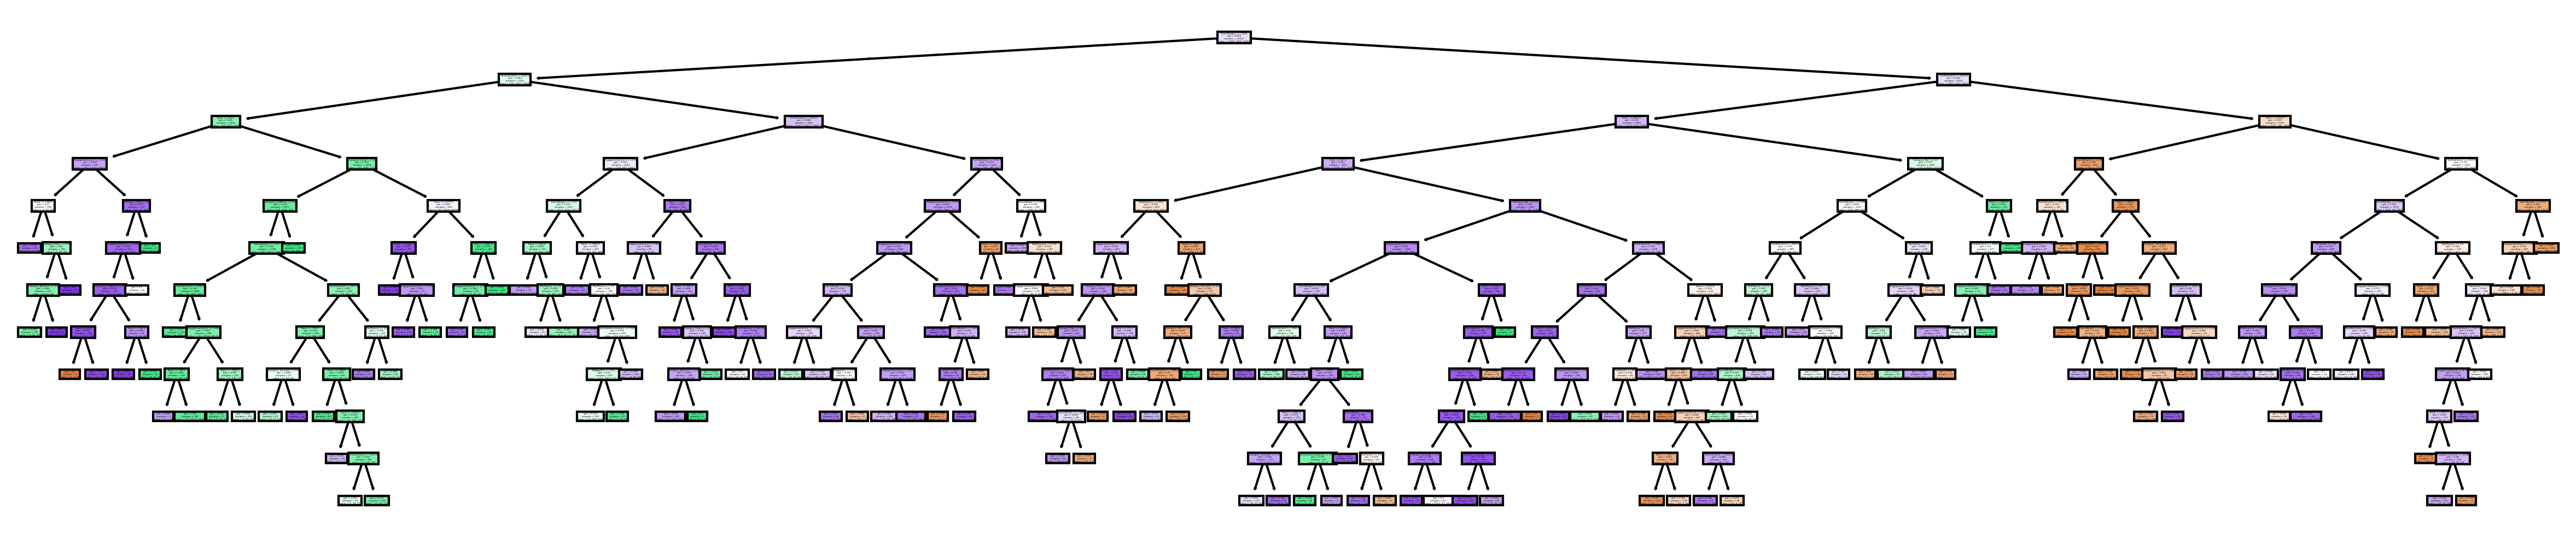

In [91]:
plt.figure(figsize=(20, 4), dpi=300)
plot_tree(dtp, feature_names=attributes, filled=True)
plt.show()

In [92]:
prune_duplicate_leaves(dtp) # prune duplicate leaves

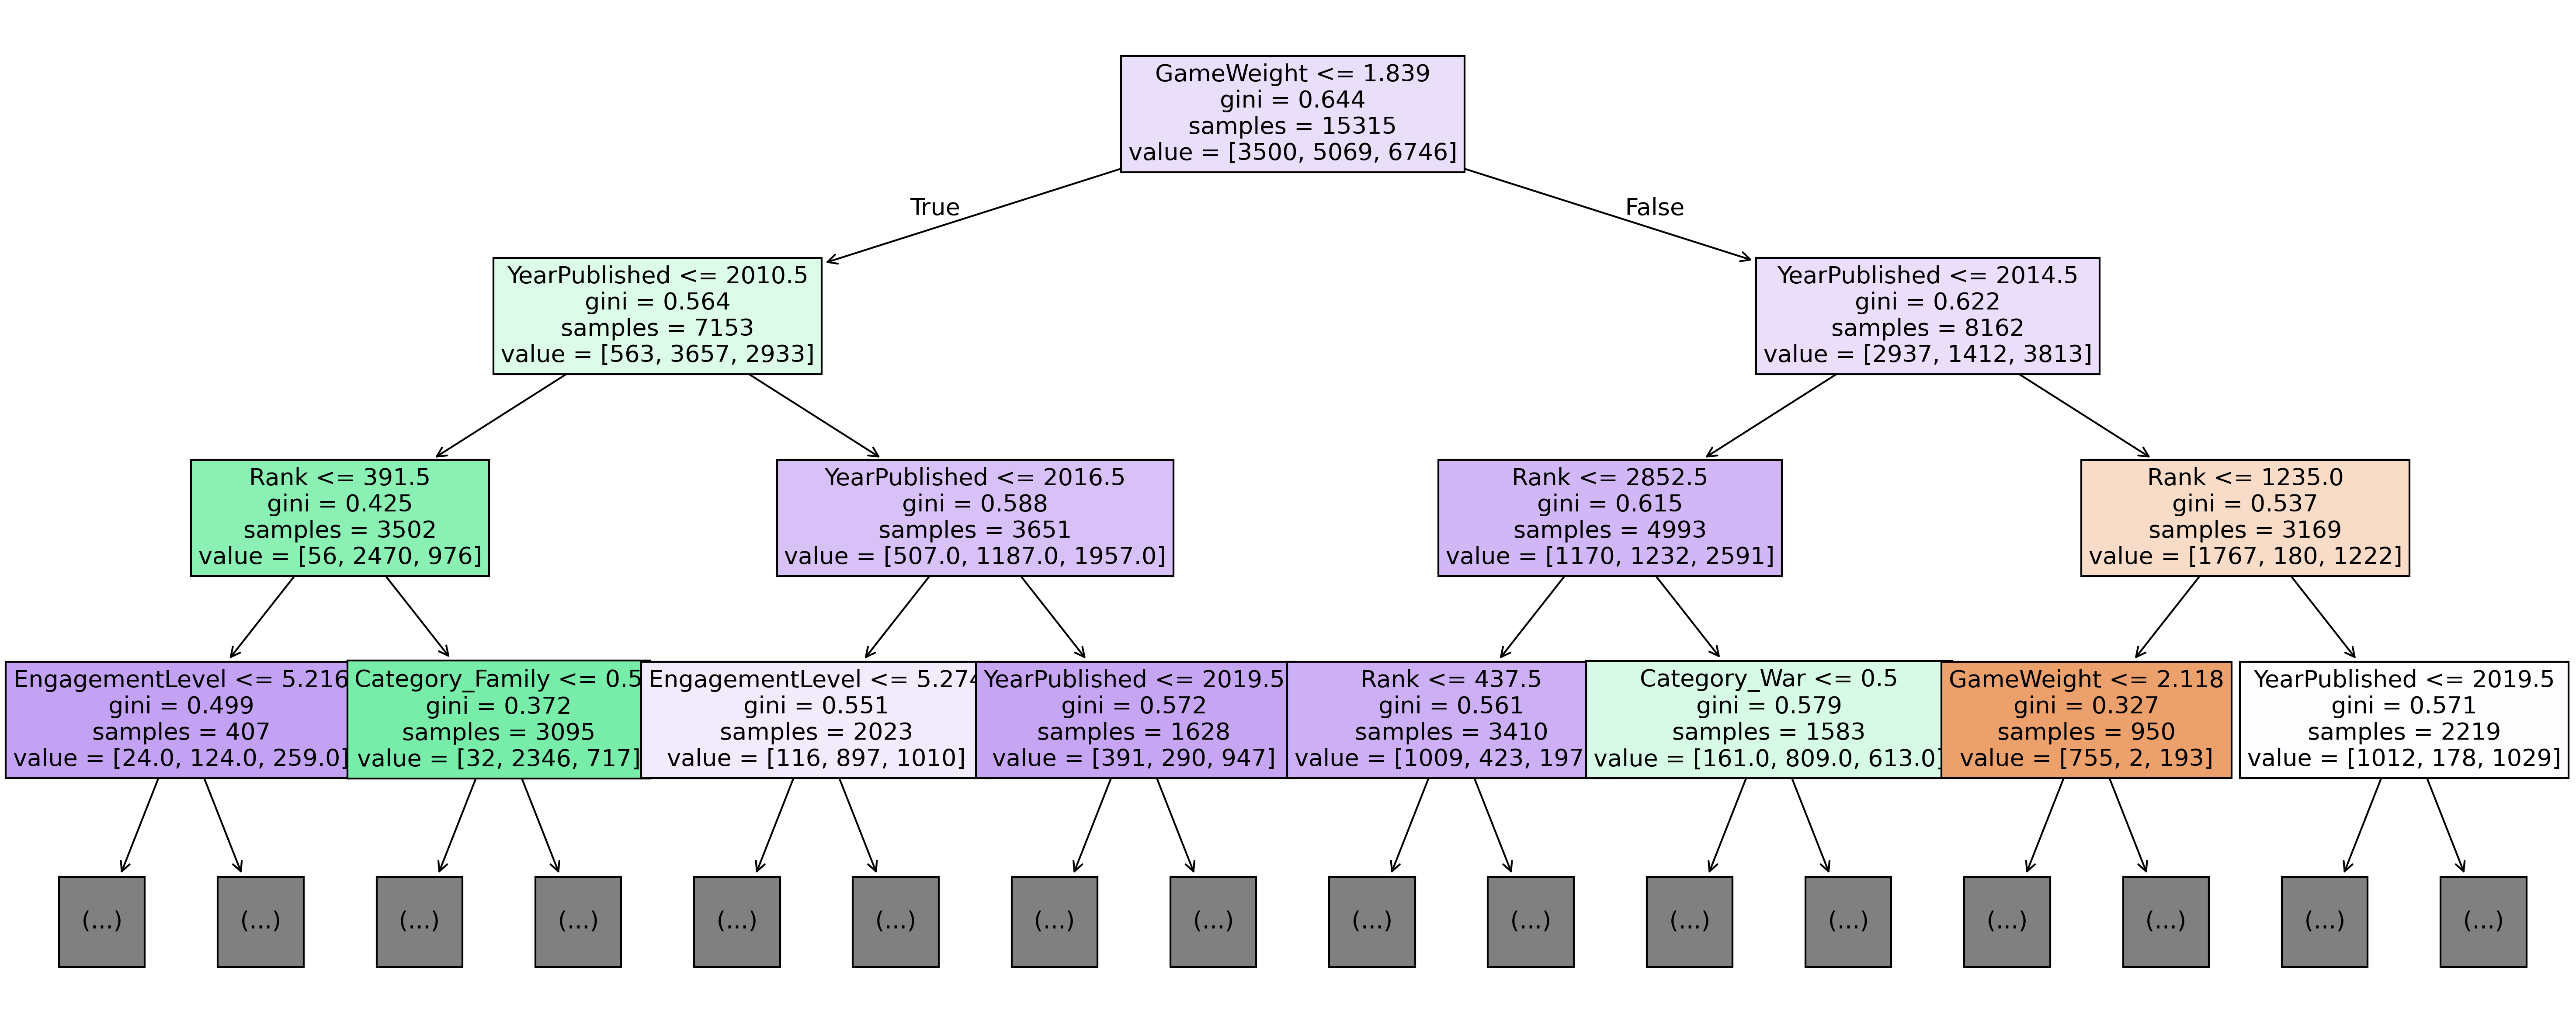

In [96]:
plt.figure(figsize=(25, 10), dpi=300)
plot_tree(dtp, feature_names=attributes, filled=True, max_depth=3, fontsize=13)
plt.show()